In [ ]:
import json
import requests
import pandas as pd

# Charger les données
base_url = "https://api-base-fastapi-mpt-dkhjb0cydga2aydc.canadacentral-01.azurewebsites.net"
api_key = ""
with open('../api.json', 'r') as file:
    api_key = json.load(file)["GH_API_KEY"]

def get_call(paths,url=base_url, params=None, header=None):
    url = f"{base_url}/{paths}"
    response = requests.get(url, params=params, headers=header)
    if response.status_code == 200:
        return response.json()
    elif response.status_code == 403:
        print("La patience est d'or. Enculé")
        response = requests.get(url, params=params, headers=header)
        return response.json()
    else:
        print(f"Error: {response.status_code} - {response.json().get('message', 'Unknown error')}")
        return None
repositories = get_call(paths="show_data",params={"page_size":100000,"page":1})

In [2]:
df = pd.DataFrame(repositories['data'])
df.to_pickle("repositories_data.pkl")
# df = df['language'].value_counts()[df['language'].value_counts()>10]

In [1]:
import pandas as pd
df = pd.read_pickle("repositories_data.pkl")
df = df[~df["language"].isin(["Python", "None"])]
df = df.dropna(subset=["language"])
df

,id,node_id,name,full_name,private,owner,html_url,description,fork,created_at,updated_at,pushed_at,language,forks_count,stargazers_count,watchers_count,open_issues_count,value
0,777395875.0,R_kgDOLlYeow,Traffic,krzychu124/Traffic,False,"{'login': 'krzychu124', 'id': 19638970, 'html_...",https://github.com/krzychu124/Traffic,"A Cities: Skylines 2 mod, the successor of TM:...",False,2024-03-25T19:17:49Z,2025-01-18T23:12:39Z,2024-12-11T10:38:57Z,C#,4.0,30.0,30.0,7.0,NaN
1,777026892.0,R_kgDOLlB9TA,ssa.to,yaklang/ssa.to,False,"{'login': 'yaklang', 'id': 84704082, 'html_url...",https://github.com/yaklang/ssa.to,https://ssa.to main page for ssa compiler utils,False,2024-03-25T03:30:14Z,2025-02-05T02:13:23Z,2025-01-10T12:15:15Z,JavaScript,1.0,30.0,30.0,0.0,NaN
2,777256184.0,R_kgDOLlP8-A,Hachimi,Hachimi-Hachimi/Hachimi,False,"{'login': 'Hachimi-Hachimi', 'id': 164894148, ...",https://github.com/Hachimi-Hachimi/Hachimi,はちみーをなめると〜 Game enhancement and translation m...,False,2024-03-25T14:04:44Z,2025-02-06T08:56:33Z,2025-01-15T07:28:14Z,Rust,0.0,30.0,30.0,13.0,NaN
3,777425295.0,R_kgDOLlaRjw,Office_365-Activator,muki01/Office_365-Activator,False,"{'login': 'muki01', 'id': 75759731, 'html_url'...",https://github.com/muki01/Office_365-Activator,This is my Office 365 Activator for Free,False,2024-03-25T20:35:50Z,2025-02-04T07:32:19Z,2024-04-10T20:47:55Z,Batchfile,10.0,30.0,30.0,0.0,NaN
7,777190949.0,R_kgDOLlL-JQ,OpenAuthenticator,Skyost/OpenAuthenticator,False,"{'login': 'Skyost', 'id': 3882599, 'html_url':...",https://github.com/Skyost/OpenAuthenticator,Secure your online accounts with Open Authenti...,False,2024-03-25T11:39:31Z,2025-02-09T13:55:10Z,2025-02-09T13:55:07Z,Dart,5.0,29.0,29.0,5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,742236393.0,R_kgDOLD2g6Q,Kobra2Insights,1coderookie/Kobra2Insights,False,"{'login': '1coderookie', 'id': 25869362, 'html...",https://github.com/1coderookie/Kobra2Insights,Comprehensive information about the Anycubic K...,False,2024-01-12T03:07:17Z,2025-02-09T04:20:41Z,2025-02-06T17:43:07Z,HTML,1.0,6.0,6.0,0.0,NaN
99996,742248009.0,R_kgDOLD3OSQ,H3-Unofficial-Community-Patch,glacier-modding/H3-Unofficial-Community-Patch,False,"{'login': 'glacier-modding', 'id': 49825397, '...",https://github.com/glacier-modding/H3-Unoffici...,Community bug fixes and stuff for Hitman 3,False,2024-01-12T03:56:19Z,2025-02-10T13:52:32Z,2025-02-08T19:42:39Z,Shell,13.0,6.0,6.0,70.0,NaN
99997,742447233.0,R_kgDOLEDYgQ,4--Vibrating-and-rotating-movement-Net-Logo,Eng-Hasan-Hajjar/4--Vibrating-and-rotating-mov...,False,"{'login': 'Eng-Hasan-Hajjar', 'id': 110938732,...",https://github.com/Eng-Hasan-Hajjar/4--Vibrati...,Vibrating and rotating movement مشروع نت لوغو...,False,2024-01-12T13:55:51Z,2024-07-07T10:10:00Z,2024-01-12T14:04:03Z,NetLogo,0.0,6.0,6.0,0.0,NaN
99998,742398933.0,R_kgDOLEAb1Q,flutter-presentation,thpir/flutter-presentation,False,"{'login': 'thpir', 'id': 92860191, 'html_url':...",https://github.com/thpir/flutter-presentation,A presentation with with Flutter deck that pro...,False,2024-01-12T11:44:09Z,2024-04-28T01:12:35Z,2024-02-01T10:53:43Z,Dart,0.0,6.0,6.0,0.0,NaN


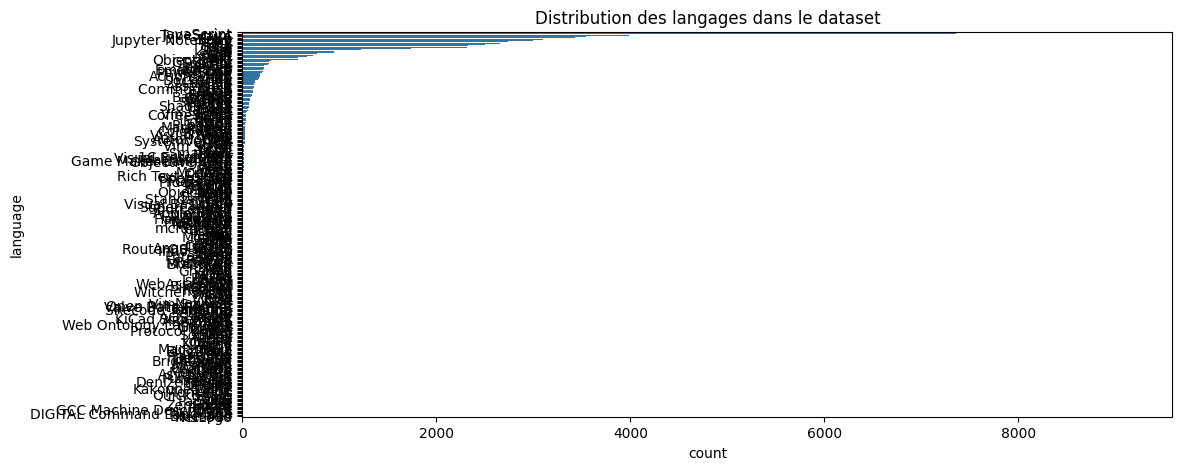

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.countplot(y=df["language"], order=df["language"].value_counts().index)
plt.title("Distribution des langages dans le dataset")
plt.show()

In [ ]:
from train import train_log

acc = train_log(df,model_name="random_forest",epochs=10, batch_size=256)
print(f"Modèle entraîné avec une accuracy de {acc}")
